# **Importing Libraries:**

In [2]:
# ======================================================
# 🔐 AI-BASED IDS USING CICIoT2023 DATASET
# ======================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import shap
import joblib

plt.style.use("ggplot")

c:\Users\Home\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# **Load the Dataset:**

In [3]:
df = pd.read_csv("datasets/train.csv")

print("Shape:", df.shape)
df.head()

Shape: (5491971, 47)


,flow_duration,Header_Length,Protocol Type,Duration,Rate,Srate,Drate,fin_flag_number,syn_flag_number,rst_flag_number,...,Std,Tot size,IAT,Number,Magnitue,Radius,Covariance,Variance,Weight,label
0,0.000000,757.00,6.00,64.00,23.671858,23.671858,0.0,0.0,0.0,0.0,...,538.470740,944.00,8.334058e+07,9.5,41.845546,761.456760,305219.322301,0.95,141.55,DDoS-ACK_Fragmentation
1,0.000000,54.00,6.00,64.00,2.393046,2.393046,0.0,0.0,1.0,0.0,...,0.000000,54.00,8.309327e+07,9.5,10.392305,0.000000,0.000000,0.00,141.55,DDoS-SYN_Flood
2,0.033982,56.78,6.11,64.64,1.192715,1.192715,0.0,0.0,0.0,0.0,...,1.727526,54.29,8.333086e+07,9.5,10.462813,2.445286,16.853118,0.19,141.55,DDoS-PSHACK_Flood
3,0.000000,0.00,47.00,64.00,9.841972,9.841972,0.0,0.0,0.0,0.0,...,0.000000,592.00,8.370278e+07,9.5,34.409301,0.000000,0.000000,0.00,141.55,Mirai-greeth_flood
4,3.944828,108.00,6.00,64.00,0.506993,0.506993,0.0,0.0,1.0,0.0,...,0.000000,54.00,8.297270e+07,9.5,10.392305,0.000000,0.000000,0.00,141.55,DoS-SYN_Flood


# **Exploratory Data Analysis:**

In [4]:
# ccheck basic info and missing values
print(df.info())
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5491971 entries, 0 to 5491970
Data columns (total 47 columns):
 #   Column           Dtype  
---  ------           -----  
 0   flow_duration    float64
 1   Header_Length    float64
 2   Protocol Type    float64
 3   Duration         float64
 4   Rate             float64
 5   Srate            float64
 6   Drate            float64
 7   fin_flag_number  float64
 8   syn_flag_number  float64
 9   rst_flag_number  float64
 10  psh_flag_number  float64
 11  ack_flag_number  float64
 12  ece_flag_number  float64
 13  cwr_flag_number  float64
 14  ack_count        float64
 15  syn_count        float64
 16  fin_count        float64
 17  urg_count        float64
 18  rst_count        float64
 19  HTTP             float64
 20  HTTPS            float64
 21  DNS              float64
 22  Telnet           float64
 23  SMTP             float64
 24  SSH              float64
 25  IRC              float64
 26  TCP              float64
 27  UDP         

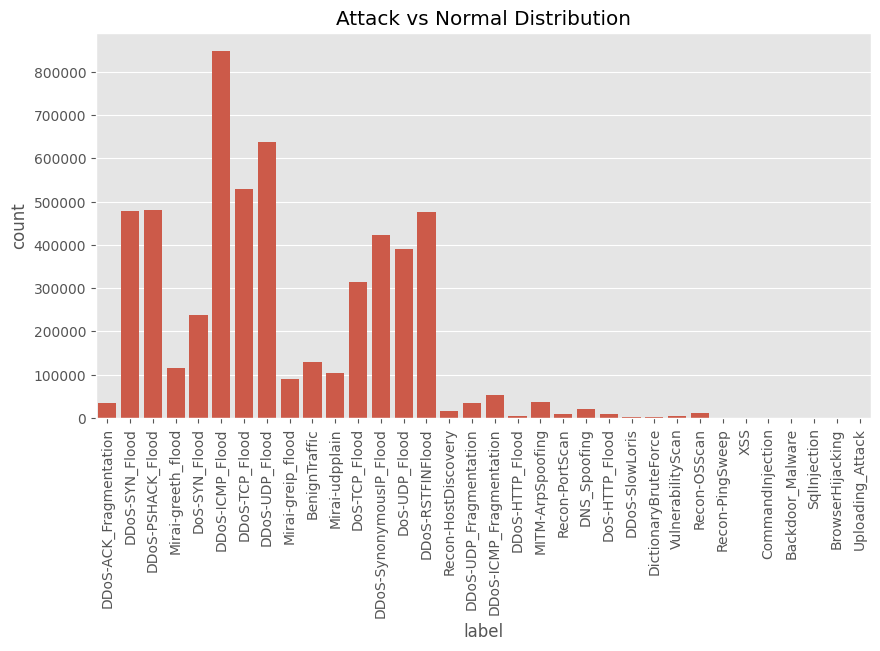

In [5]:
# class distribution
plt.figure(figsize=(10,5))
sns.countplot(x=df['label'])
plt.xticks(rotation=90)
plt.title("Attack vs Normal Distribution")
plt.show()

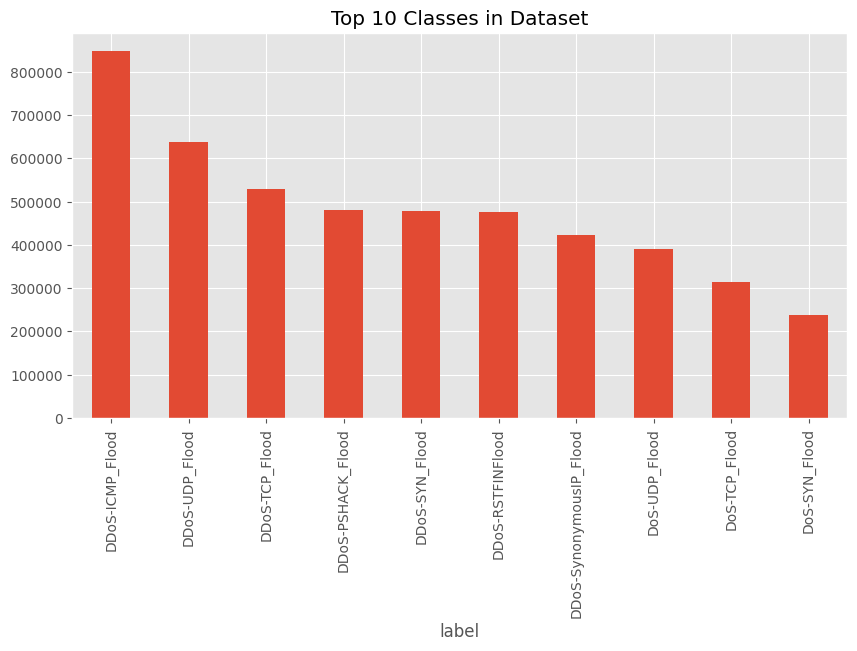

In [6]:
# top attack types
df['label'].value_counts().head(10).plot(kind='bar', figsize=(10,5))
plt.title("Top 10 Classes in Dataset")
plt.show()

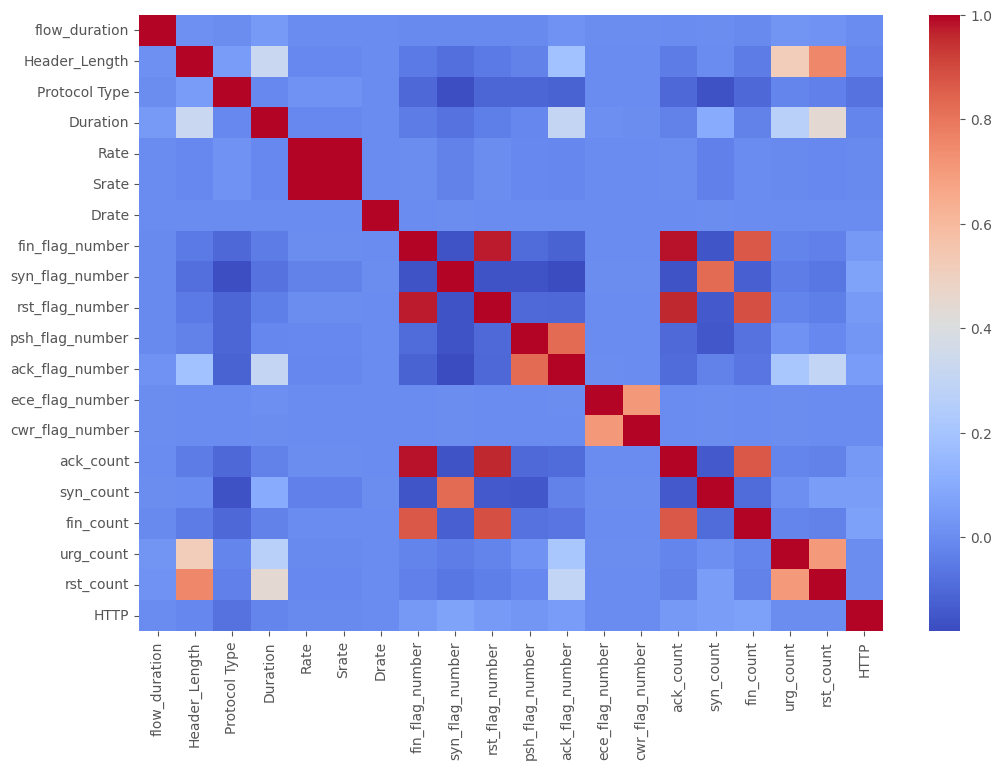

In [7]:
# Correlation Heatmap (feature insight)
corr = df.select_dtypes(include=np.number).corr()

plt.figure(figsize=(12,8))
sns.heatmap(corr.iloc[:20, :20], cmap="coolwarm")
plt.show()

In [8]:
# data cleaning
df = df.dropna()
df = df.drop_duplicates()

print("After Cleaning:", df.shape)

After Cleaning: (5357406, 47)


# **Label Encoding:**

In [9]:
label_encoder = LabelEncoder()
df['label'] = label_encoder.fit_transform(df['label'])

joblib.dump(label_encoder, "model/label_encoder.pkl")

['model/label_encoder.pkl']

In [10]:
# Encode categorical features 
for col in df.select_dtypes(include='object').columns:
    if col != 'label':
        df[col] = LabelEncoder().fit_transform(df[col])

# **Train-Test Split:**

In [11]:
X = df.drop("label", axis=1)
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# **Feature Scaling:**

In [12]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

joblib.dump(scaler, "model/scaler.pkl")

['model/scaler.pkl']

# **Model Training:**

In [13]:
# random forest 
model = RandomForestClassifier(
    n_estimators=150,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

,n_estimators,150
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [14]:
# model evaluation 
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.9945916030320622

Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.06      0.12        78
           1       0.89      0.99      0.94     25279
           2       0.93      0.29      0.44       129
           3       0.86      0.16      0.26       122
           4       1.00      0.99      0.99      6556
           5       0.99      0.97      0.98       658
           6       1.00      1.00      1.00    165457
           7       0.99      1.00      1.00     10351
           8       1.00      1.00      1.00     93901
           9       1.00      1.00      1.00     92751
          10       1.00      1.00      1.00     93396
          11       0.92      0.99      0.95       538
          12       1.00      1.00      1.00     82339
          13       1.00      1.00      1.00    103106
          14       1.00      1.00      1.00    124406
          15       1.00      0.99      0.99      6665
          16       0.82    

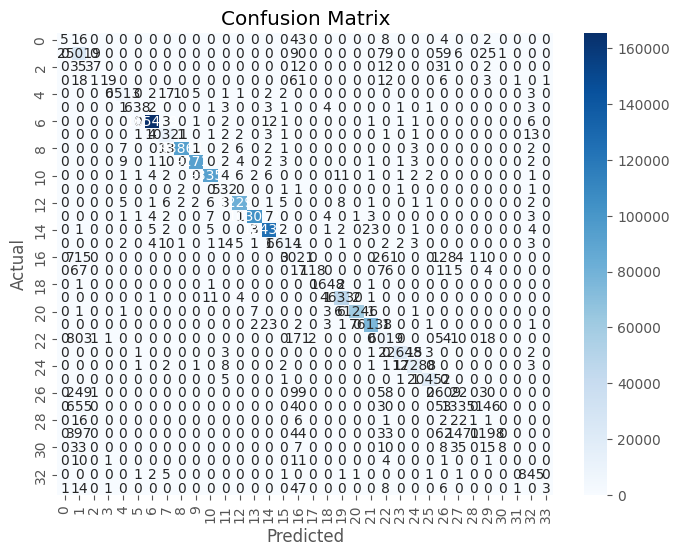

In [ ]:
# confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(15,7))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

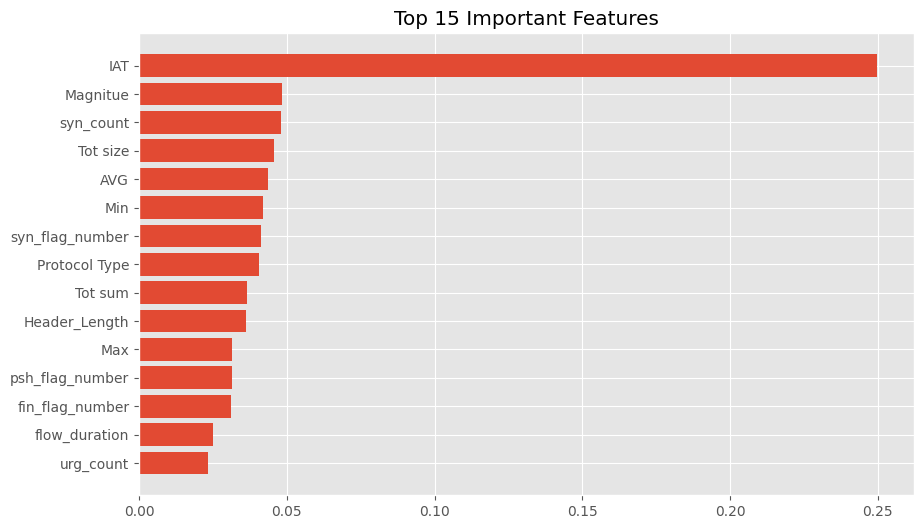

In [16]:
# feature importance
importances = model.feature_importances_
indices = np.argsort(importances)[-15:]

plt.figure(figsize=(10,6))
plt.title("Top 15 Important Features")
plt.barh(range(len(indices)), importances[indices])
plt.yticks(range(len(indices)), X.columns[indices])
plt.show()

# **SHAP:**

In [17]:
# SHAP explainability
explainer = shap.TreeExplainer(model)

shap_values = explainer.shap_values(X_test[:200])

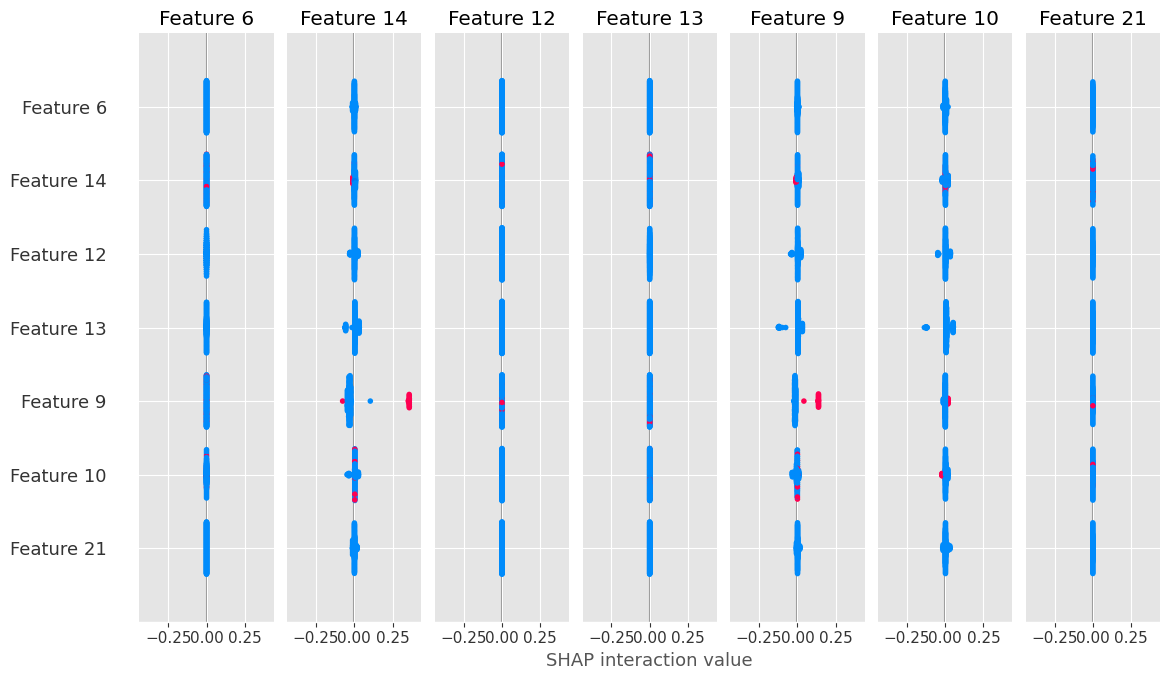

In [18]:
# SHAP summary plot
shap.summary_plot(shap_values, X_test[:200])

In [22]:
# SHAP force plot for a single prediction
class_index = 0  # change if needed

shap.force_plot(
    explainer.expected_value[class_index],
    shap_values[0][:, class_index],
    X_test.iloc[0],
    matplotlib=True
)

AttributeError: 'numpy.ndarray' object has no attribute 'iloc'

In [23]:
# saved models

joblib.dump(model, "model/ids_model.pkl")
joblib.dump(scaler, "model/scaler.pkl")
joblib.dump(label_encoder, "model/label_encoder.pkl")

print("All files saved successfully!")

All files saved successfully!
